In [4]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\fantasy_id")

print(DATASET_DIR.exists())
print(DATASET_DIR)

True
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\fantasy_id


In [5]:
def show_folder_tree(root_path, max_depth=3):
    root_path = Path(root_path)

    for current_root, dirs, files in os.walk(root_path):
        level = len(Path(current_root).relative_to(root_path).parts)

        if level > max_depth:
            continue

        indent = "    " * level
        print(f"{indent}{Path(current_root).name}/")

        subindent = "    " * (level + 1)
        for f in files[:10]:
            print(f"{subindent}{f}")

        if len(files) > 10:
            print(f"{subindent}... ({len(files)} files)")

In [6]:
show_folder_tree(DATASET_DIR, max_depth=3)

fantasy_id/
    generate_csv.py
    README.md
    test.csv
    train.csv
    examples/
        chinese-NF-1042.png
        indian-038_03.jpg
        portugal-066_03-d2.jpg
        portugal-066_03.jpg
        turkiye-036_03.png
        ukraine-NF-1084.jpg
        usa-NF-1004-d1.jpg
        usa-NF-1004.jpg
    test/
        attack/
            digital_3/
                .DS_Store
            facedancer/
                .DS_Store
            textdiffuserft_bfei/
                .DS_Store
        bonafide/
            huawei/
                chinese2-flickr_F_16745558933_a3f9fe2bc9_k.jpg
                chinese2-flickr_F_16745558933_a3f9fe2bc9_k.json
                chinese2-flickr_F_16858102101_d4c5c1e7a2_c.jpg
                chinese2-flickr_F_16858102101_d4c5c1e7a2_c.json
                chinese2-flickr_F_17178039488_60828ef8de_k.jpg
                chinese2-flickr_F_17178039488_60828ef8de_k.json
                chinese2-flickr_F_17619703551_9705002b22_b.jpg
                chinese2-fli

structure tells us:

train/ and test/ already exist
bonafide/ = genuine documents
attack/ = manipulated documents
inside bonafide/ you have capture types like:
huawei
iphone15
iphone15pro
scan
inside attack/ you have attack types like:
digital_1
digital_2
digital_3
facedancer
textdiffuserft_bfei

In [7]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.fantasyid_preprocessing import build_fantasyid_dataframe

In [8]:
from pathlib import Path

DATASET_DIR = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\fantasy_id")
print(DATASET_DIR.exists())
print(DATASET_DIR)

True
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\fantasy_id


In [9]:
df_fantasy = build_fantasyid_dataframe(DATASET_DIR)
df_fantasy.head()

,image_id,image_path,relative_path,filename,suffix,split,class_name,image_label,capture_type,attack_type,width,height
0,chinese-NF-1042,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,examples\chinese-NF-1042.png,chinese-NF-1042.png,.png,None,None,NaN,None,None,3488,2200
1,indian-038_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,examples\indian-038_03.jpg,indian-038_03.jpg,.jpg,None,None,NaN,None,None,2802,1780
2,portugal-066_03-d2,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,examples\portugal-066_03-d2.jpg,portugal-066_03-d2.jpg,.jpg,None,None,NaN,None,None,2868,1796
3,portugal-066_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,examples\portugal-066_03.jpg,portugal-066_03.jpg,.jpg,None,None,NaN,None,None,2868,1796
4,turkiye-036_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,examples\turkiye-036_03.png,turkiye-036_03.png,.png,None,None,NaN,None,None,3488,2200


In [10]:
print(df_fantasy.shape)
print(df_fantasy.columns.tolist())

(3292, 12)
['image_id', 'image_path', 'relative_path', 'filename', 'suffix', 'split', 'class_name', 'image_label', 'capture_type', 'attack_type', 'width', 'height']


In [11]:
print("Class counts:")
print(df_fantasy["class_name"].value_counts())

print("\nLabel counts:")
print(df_fantasy["image_label"].value_counts())

print("\nSplit counts:")
print(df_fantasy["split"].value_counts())

print("\nSplit x label:")
print(pd.crosstab(df_fantasy["split"], df_fantasy["image_label"]))

Class counts:
class_name
attack      2351
bonafide     933
Name: count, dtype: int64

Label counts:
image_label
1.0    2351
0.0     933
Name: count, dtype: int64

Split counts:
split
train    1899
test     1385
Name: count, dtype: int64

Split x label:
image_label  0.0   1.0
split                 
test         300  1085
train        633  1266


In [12]:
bonafide_df = df_fantasy[df_fantasy["class_name"] == "bonafide"]

print(bonafide_df["capture_type"].value_counts(dropna=False))

capture_type
huawei         311
scan           311
iphone15pro    211
iphone15       100
Name: count, dtype: int64


In [13]:
attack_df = df_fantasy[df_fantasy["class_name"] == "attack"]

print(attack_df["attack_type"].value_counts(dropna=False))

attack_type
digital_3              786
digital_2              633
digital_1              633
facedancer             150
textdiffuserft_bfei    149
Name: count, dtype: int64


In [14]:
def plot_counts(series, title, rotation=0):
    plt.figure(figsize=(8, 4))
    series.value_counts().plot(kind="bar")
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

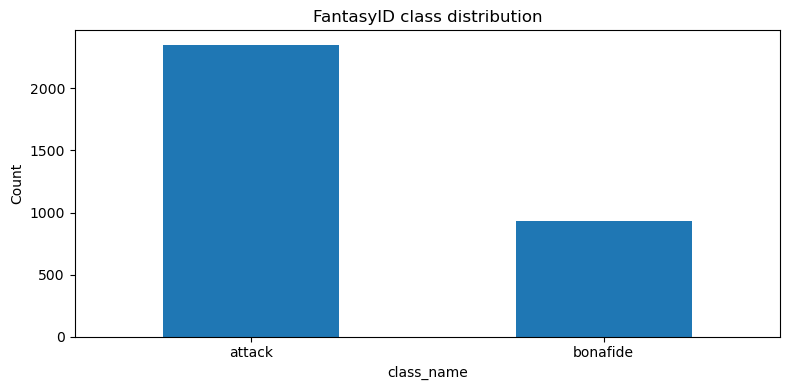

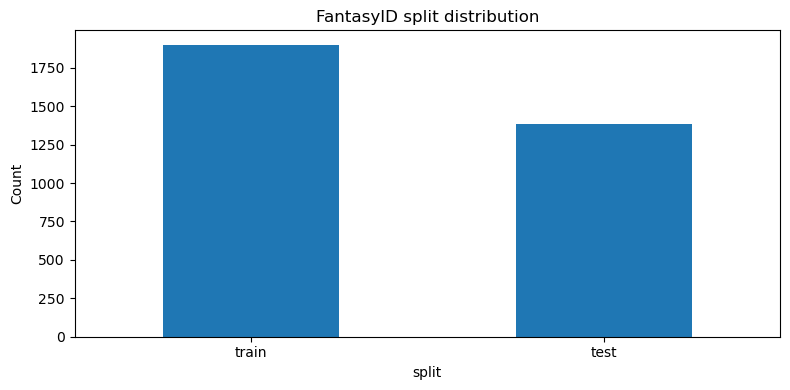

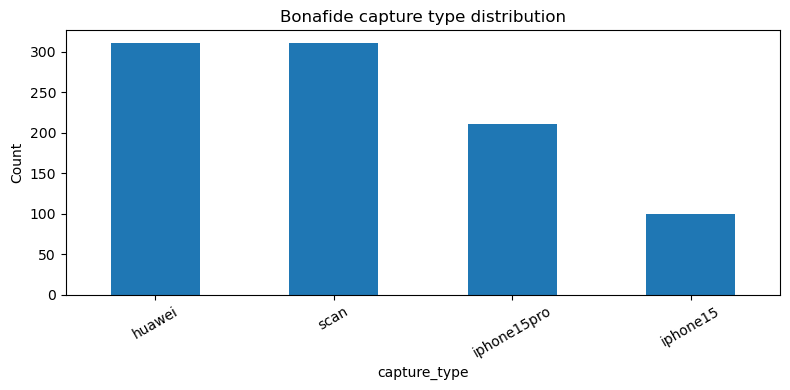

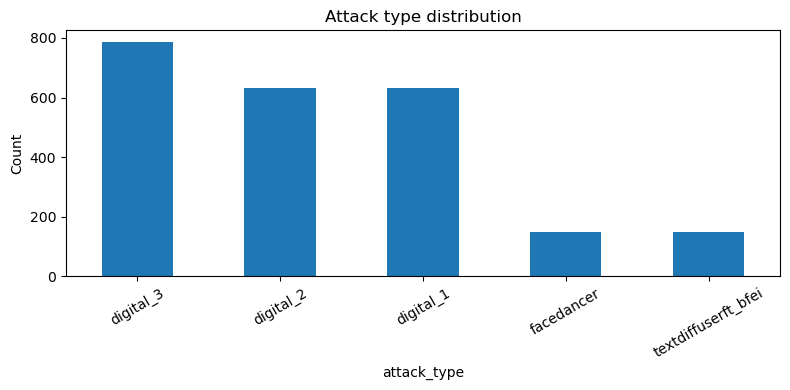

In [15]:
plot_counts(df_fantasy["class_name"], "FantasyID class distribution")
plot_counts(df_fantasy["split"], "FantasyID split distribution")
plot_counts(bonafide_df["capture_type"], "Bonafide capture type distribution", rotation=30)
plot_counts(attack_df["attack_type"], "Attack type distribution", rotation=30)

In [16]:
def show_sample_images(df, n=5, random_state=42):
    sample_df = df.sample(min(n, len(df)), random_state=random_state)

    plt.figure(figsize=(14, 4 * len(sample_df)))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["image_path"])

        plt.subplot(len(sample_df), 1, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"split={row['split']} | class={row['class_name']} | "
            f"capture={row['capture_type']} | attack={row['attack_type']}\n"
            f"{row['relative_path']}"
        )

    plt.tight_layout()
    plt.show()

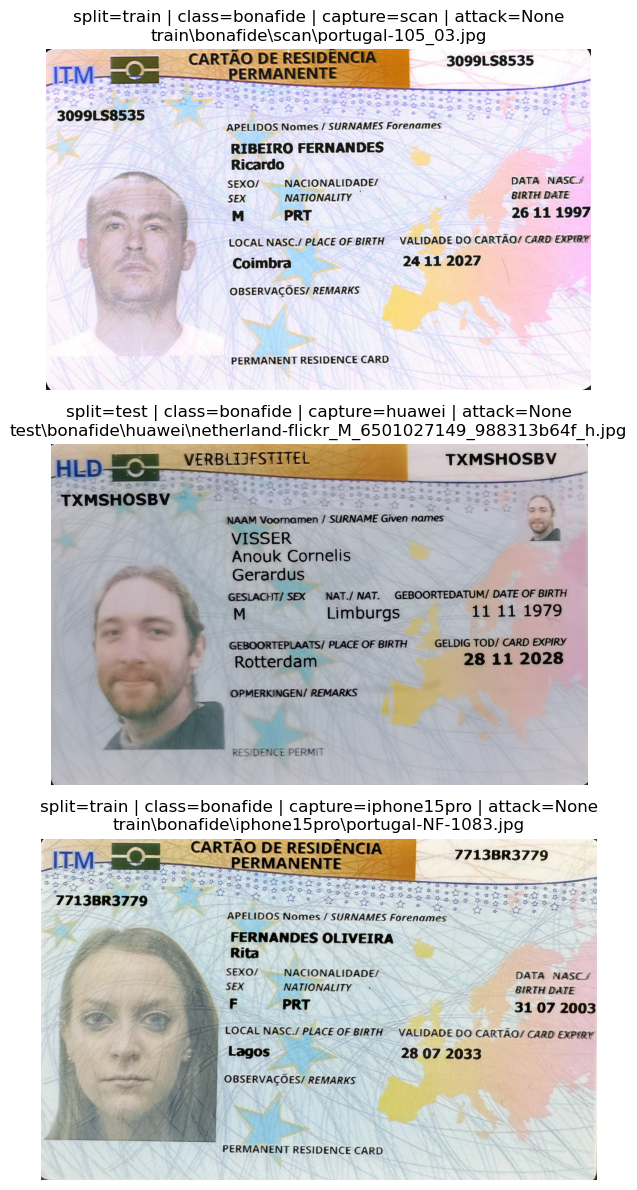

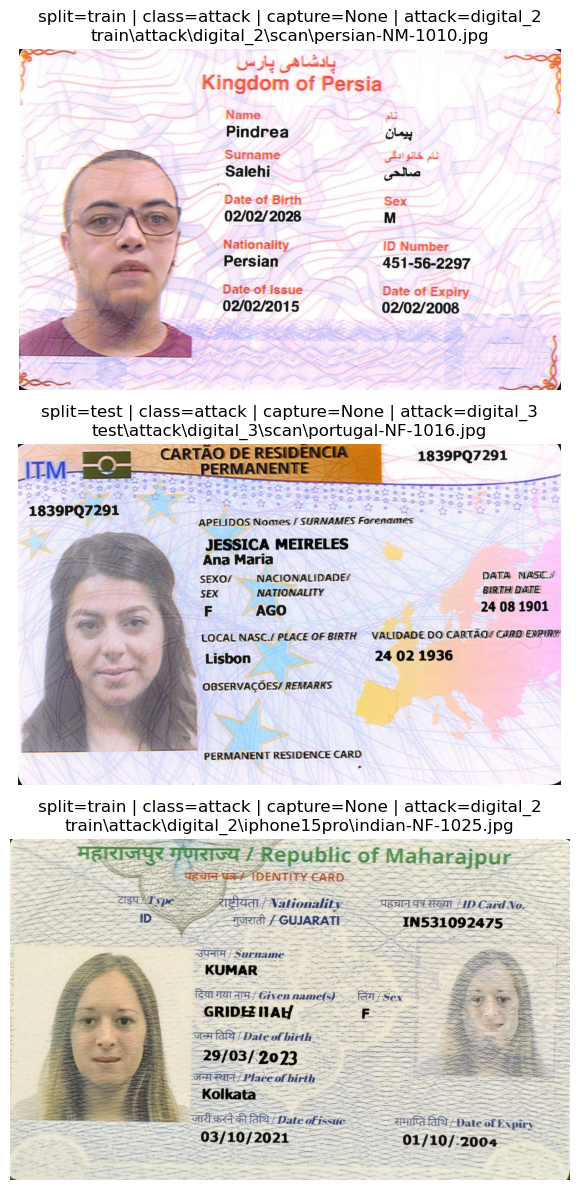

In [17]:
show_sample_images(df_fantasy[df_fantasy["class_name"] == "bonafide"], n=3)
show_sample_images(df_fantasy[df_fantasy["class_name"] == "attack"], n=3)

In [18]:
output_path = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_metadata.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_fantasy.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_metadata.csv


In [19]:
df_fantasy = build_fantasyid_dataframe(DATASET_DIR)

print(df_fantasy.shape)
print(df_fantasy.head())
print(pd.crosstab(df_fantasy["split"], df_fantasy["class_name"]))
print(df_fantasy[df_fantasy["class_name"] == "attack"]["attack_type"].value_counts())

(3292, 12)
             image_id                                         image_path  \
0     chinese-NF-1042  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
1       indian-038_03  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
2  portugal-066_03-d2  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
3     portugal-066_03  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
4      turkiye-036_03  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   

                     relative_path                filename suffix split  \
0     examples\chinese-NF-1042.png     chinese-NF-1042.png   .png  None   
1       examples\indian-038_03.jpg       indian-038_03.jpg   .jpg  None   
2  examples\portugal-066_03-d2.jpg  portugal-066_03-d2.jpg   .jpg  None   
3     examples\portugal-066_03.jpg     portugal-066_03.jpg   .jpg  None   
4      examples\turkiye-036_03.png      turkiye-036_03.png   .png  None   

  class_name  image_label capture_type attack_type  width  height  
0       None 

In [20]:
df_fantasy_clean = df_fantasy[df_fantasy["split"].notna()].copy()

print(df_fantasy_clean.shape)
print(df_fantasy_clean["split"].value_counts())
print(df_fantasy_clean["class_name"].value_counts())

(3284, 12)
split
train    1899
test     1385
Name: count, dtype: int64
class_name
attack      2351
bonafide     933
Name: count, dtype: int64


In [21]:
df_fantasy[df_fantasy["split"].isna()][["relative_path", "filename"]]

,relative_path,filename
0,examples\chinese-NF-1042.png,chinese-NF-1042.png
1,examples\indian-038_03.jpg,indian-038_03.jpg
2,examples\portugal-066_03-d2.jpg,portugal-066_03-d2.jpg
3,examples\portugal-066_03.jpg,portugal-066_03.jpg
4,examples\turkiye-036_03.png,turkiye-036_03.png
5,examples\ukraine-NF-1084.jpg,ukraine-NF-1084.jpg
6,examples\usa-NF-1004-d1.jpg,usa-NF-1004-d1.jpg
7,examples\usa-NF-1004.jpg,usa-NF-1004.jpg


In [22]:
print("Label counts:")
print(df_fantasy_clean["image_label"].value_counts())

print("\nSplit x label:")
print(pd.crosstab(df_fantasy_clean["split"], df_fantasy_clean["image_label"]))

Label counts:
image_label
1.0    2351
0.0     933
Name: count, dtype: int64

Split x label:
image_label  0.0   1.0
split                 
test         300  1085
train        633  1266


In [23]:
def plot_counts(series, title, rotation=0):
    plt.figure(figsize=(8, 4))
    series.value_counts().plot(kind="bar")
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

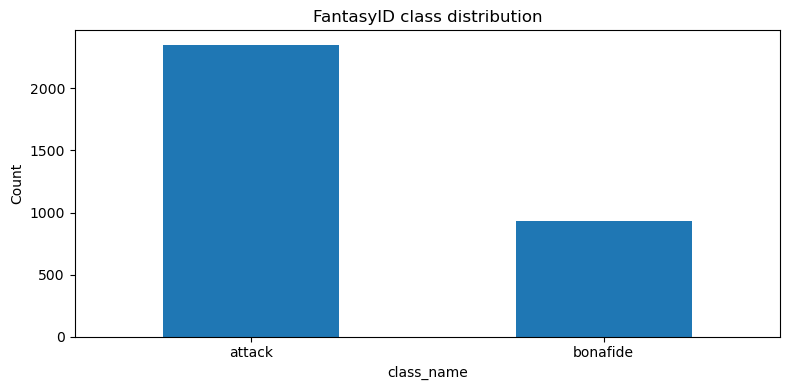

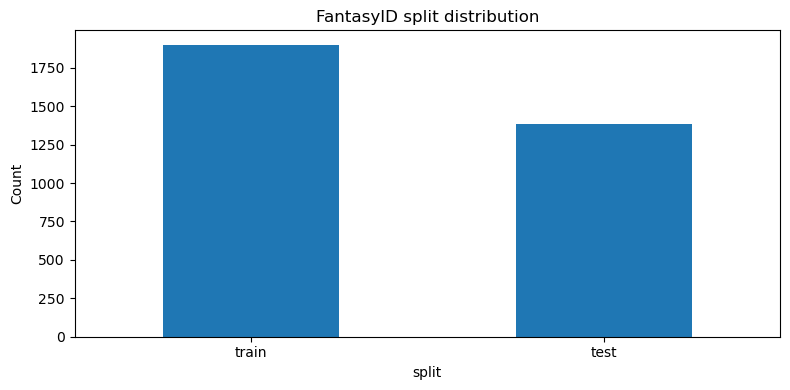

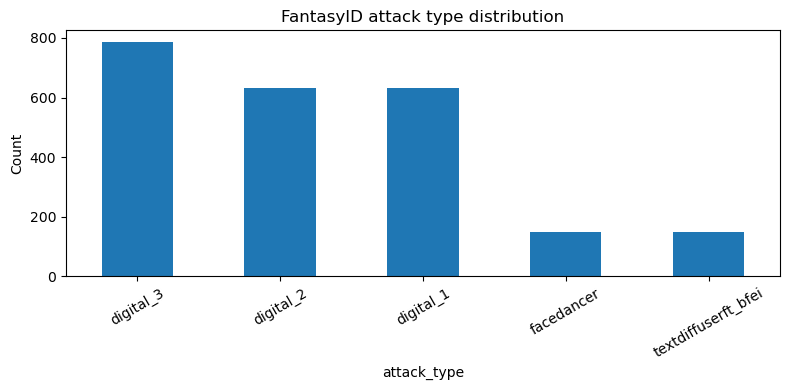

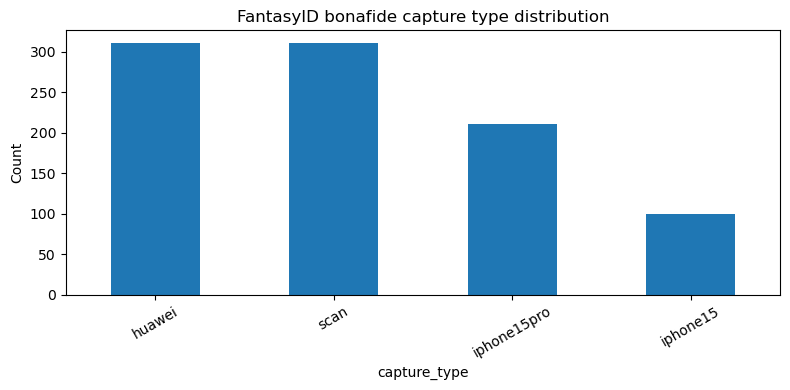

In [24]:
plot_counts(df_fantasy_clean["class_name"], "FantasyID class distribution")
plot_counts(df_fantasy_clean["split"], "FantasyID split distribution")
plot_counts(
    df_fantasy_clean[df_fantasy_clean["class_name"] == "attack"]["attack_type"],
    "FantasyID attack type distribution",
    rotation=30
)
plot_counts(
    df_fantasy_clean[df_fantasy_clean["class_name"] == "bonafide"]["capture_type"],
    "FantasyID bonafide capture type distribution",
    rotation=30
)

In [25]:
output_path = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_metadata_clean.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_fantasy_clean.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_metadata_clean.csv


In [26]:
train_csv = pd.read_csv(DATASET_DIR / "train.csv")
test_csv = pd.read_csv(DATASET_DIR / "test.csv")

print("TRAIN CSV")
print(train_csv.shape)
print(train_csv.head())
print(train_csv.columns.tolist())

print("\nTEST CSV")
print(test_csv.shape)
print(test_csv.head())
print(test_csv.columns.tolist())

TRAIN CSV
(1899, 3)
                                      path  is_attack attack_type
0  train/bonafide/huawei/arabic-003_03.jpg      False        none
1  train/bonafide/huawei/arabic-005_03.jpg      False        none
2  train/bonafide/huawei/arabic-024_03.jpg      False        none
3  train/bonafide/huawei/arabic-112_03.jpg      False        none
4  train/bonafide/huawei/arabic-120_03.jpg      False        none
['path', 'is_attack', 'attack_type']

TEST CSV
(1385, 3)
                                                path  is_attack attack_type
0  test/attack/facedancer/huawei/netherland-flick...       True        face
1  test/attack/facedancer/huawei/singapore-flickr...       True        face
2  test/attack/facedancer/huawei/singapore-flickr...       True        face
3  test/attack/facedancer/huawei/netherland-flick...       True        face
4  test/attack/facedancer/huawei/chinese2-flickr_...       True        face
['path', 'is_attack', 'attack_type']


In [27]:
import json

sample_json_path = next(DATASET_DIR.rglob("*.json"))
print(sample_json_path)

with open(sample_json_path, "r", encoding="utf-8") as f:
    sample_json = json.load(f)

print(type(sample_json))
print(sample_json)

C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\fantasy_id\train\bonafide\huawei\arabic-003_03.json
<class 'dict'>
{'person_info': {'gender': 'F', 'face_id': '003_03', 'face_db': 'facelab_london'}, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 1097, 'y': 696, 'width': 739, 'height': 113}, 'region_attributes': {'field_name': 'Name', 'val': 'Tariq Al-Ahmad', 'language': 'english'}}, {'shape_attributes': {'name': 'rect', 'x': 1064, 'y': 490, 'width': 601, 'height': 113}, 'region_attributes': {'field_name': '/الإسم', 'val': 'طارق الأحمد', 'language': 'arabic'}}, {'shape_attributes': {'name': 'rect', 'x': 1107, 'y': 1162, 'width': 582, 'height': 116}, 'region_attributes': {'field_name': 'dob', 'val': '29 Apr 1985', 'language': 'english'}}, {'shape_attributes': {'name': 'rect', 'x': 1912, 'y': 1156, 'width': 839, 'height': 113}, 'region_attributes': {'field_name': 'تاريخ الميلاد', 'val': '٢٩ /أبريل/ ١٩٨٥', 'language': 'arabic'}}, {'shape_attributes': {'name': 'r

In [28]:
print(sample_json.keys() if isinstance(sample_json, dict) else type(sample_json))

dict_keys(['person_info', 'regions', 'cropping_info'])


In [32]:
print("TRAIN COLUMNS:", train_csv.columns.tolist())
print("TEST COLUMNS:", test_csv.columns.tolist())

print("\nTRAIN SHAPE:", train_csv.shape)
print("TEST SHAPE:", test_csv.shape)

print("\nTRAIN is_attack counts:")
print(train_csv["is_attack"].value_counts(dropna=False))

print("\nTEST is_attack counts:")
print(test_csv["is_attack"].value_counts(dropna=False))

print("\nTRAIN attack_type counts:")
print(train_csv["attack_type"].value_counts(dropna=False))

print("\nTEST attack_type counts:")
print(test_csv["attack_type"].value_counts(dropna=False))

TRAIN COLUMNS: ['path', 'is_attack', 'attack_type']
TEST COLUMNS: ['path', 'is_attack', 'attack_type']

TRAIN SHAPE: (1899, 3)
TEST SHAPE: (1385, 3)

TRAIN is_attack counts:
is_attack
True     1266
False     633
Name: count, dtype: int64

TEST is_attack counts:
is_attack
True     1085
False     300
Name: count, dtype: int64

TRAIN attack_type counts:
attack_type
face_text    1266
none          633
Name: count, dtype: int64

TEST attack_type counts:
attack_type
text    935
none    300
face    150
Name: count, dtype: int64


In [33]:
df_fantasy_clean["relative_path_norm"] = (
    df_fantasy_clean["relative_path"]
    .str.replace("\\", "/", regex=False)
    .str.strip()
)

train_csv["path_norm"] = train_csv["path"].str.strip()
test_csv["path_norm"] = test_csv["path"].str.strip()

In [34]:
train_csv["csv_split"] = "train"
test_csv["csv_split"] = "test"

df_csv_meta = pd.concat([train_csv, test_csv], ignore_index=True)

print(df_csv_meta.shape)
print(df_csv_meta.head())

(3284, 5)
                                      path  is_attack attack_type  \
0  train/bonafide/huawei/arabic-003_03.jpg      False        none   
1  train/bonafide/huawei/arabic-005_03.jpg      False        none   
2  train/bonafide/huawei/arabic-024_03.jpg      False        none   
3  train/bonafide/huawei/arabic-112_03.jpg      False        none   
4  train/bonafide/huawei/arabic-120_03.jpg      False        none   

                                 path_norm csv_split  
0  train/bonafide/huawei/arabic-003_03.jpg     train  
1  train/bonafide/huawei/arabic-005_03.jpg     train  
2  train/bonafide/huawei/arabic-024_03.jpg     train  
3  train/bonafide/huawei/arabic-112_03.jpg     train  
4  train/bonafide/huawei/arabic-120_03.jpg     train  


In [35]:
df_fantasy_merged = df_fantasy_clean.merge(
    df_csv_meta,
    left_on="relative_path_norm",
    right_on="path_norm",
    how="left"
)

print(df_fantasy_merged.shape)
df_fantasy_merged.head()

(3284, 18)


,image_id,image_path,relative_path,filename,suffix,split,class_name,image_label,capture_type,attack_type_x,width,height,relative_path_norm,path,is_attack,attack_type_y,path_norm,csv_split
0,arabic-003_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test\attack\digital_3\huawei\arabic-003_03.jpg,arabic-003_03.jpg,.jpg,test,attack,1.0,None,digital_3,3023,1884,test/attack/digital_3/huawei/arabic-003_03.jpg,test/attack/digital_3/huawei/arabic-003_03.jpg,True,text,test/attack/digital_3/huawei/arabic-003_03.jpg,test
1,arabic-005_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test\attack\digital_3\huawei\arabic-005_03.jpg,arabic-005_03.jpg,.jpg,test,attack,1.0,None,digital_3,3068,1882,test/attack/digital_3/huawei/arabic-005_03.jpg,test/attack/digital_3/huawei/arabic-005_03.jpg,True,text,test/attack/digital_3/huawei/arabic-005_03.jpg,test
2,arabic-01_0002_000-c7338db1_1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test\attack\digital_3\huawei\arabic-01_0002_00...,arabic-01_0002_000-c7338db1_1.jpg,.jpg,test,attack,1.0,None,digital_3,3216,2013,test/attack/digital_3/huawei/arabic-01_0002_00...,test/attack/digital_3/huawei/arabic-01_0002_00...,True,text,test/attack/digital_3/huawei/arabic-01_0002_00...,test
3,arabic-01_0076_000-fd5000df_1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test\attack\digital_3\huawei\arabic-01_0076_00...,arabic-01_0076_000-fd5000df_1.jpg,.jpg,test,attack,1.0,None,digital_3,3208,1976,test/attack/digital_3/huawei/arabic-01_0076_00...,test/attack/digital_3/huawei/arabic-01_0076_00...,True,text,test/attack/digital_3/huawei/arabic-01_0076_00...,test
4,arabic-01_0095_000-18471808_1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test\attack\digital_3\huawei\arabic-01_0095_00...,arabic-01_0095_000-18471808_1.jpg,.jpg,test,attack,1.0,None,digital_3,3185,1971,test/attack/digital_3/huawei/arabic-01_0095_00...,test/attack/digital_3/huawei/arabic-01_0095_00...,True,text,test/attack/digital_3/huawei/arabic-01_0095_00...,test


In [36]:
print("Missing CSV rows:", df_fantasy_merged["is_attack"].isna().sum())

print("\nFolder label vs CSV label:")
print(pd.crosstab(df_fantasy_merged["image_label"], df_fantasy_merged["is_attack"]))

print("\nFolder split vs CSV split:")
print(pd.crosstab(df_fantasy_merged["split"], df_fantasy_merged["csv_split"]))

Missing CSV rows: 0

Folder label vs CSV label:
is_attack    False  True 
image_label              
0.0            933      0
1.0              0   2351

Folder split vs CSV split:
csv_split  test  train
split                 
test       1385      0
train         0   1899


In [37]:
print(df_fantasy_merged.columns.tolist())

['image_id', 'image_path', 'relative_path', 'filename', 'suffix', 'split', 'class_name', 'image_label', 'capture_type', 'attack_type_x', 'width', 'height', 'relative_path_norm', 'path', 'is_attack', 'attack_type_y', 'path_norm', 'csv_split']


In [38]:
df_fantasy_merged["is_attack_final"] = df_fantasy_merged["is_attack"].astype(int)

df_fantasy_merged["attack_type_final"] = df_fantasy_merged["attack_type_y"]

df_fantasy_merged["attack_group"] = df_fantasy_merged["attack_type_final"].replace({
    "none": "bonafide",
    "face": "attack",
    "text": "attack",
    "face_text": "attack"
})

In [39]:
df_fantasy_final = df_fantasy_merged[
    [
        "image_id",
        "image_path",
        "relative_path",
        "split",
        "class_name",
        "image_label",
        "is_attack_final",
        "attack_type_final",
        "attack_group",
        "capture_type",
        "width",
        "height"
    ]
].copy()

In [40]:
print(df_fantasy_final.shape)
print(df_fantasy_final.head())

print(df_fantasy_final["attack_type_final"].value_counts(dropna=False))
print(df_fantasy_final["attack_group"].value_counts(dropna=False))

(3284, 12)
                        image_id  \
0                  arabic-003_03   
1                  arabic-005_03   
2  arabic-01_0002_000-c7338db1_1   
3  arabic-01_0076_000-fd5000df_1   
4  arabic-01_0095_000-18471808_1   

                                          image_path  \
0  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
1  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
2  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
3  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
4  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   

                                       relative_path split class_name  \
0     test\attack\digital_3\huawei\arabic-003_03.jpg  test     attack   
1     test\attack\digital_3\huawei\arabic-005_03.jpg  test     attack   
2  test\attack\digital_3\huawei\arabic-01_0002_00...  test     attack   
3  test\attack\digital_3\huawei\arabic-01_0076_00...  test     attack   
4  test\attack\digital_3\huawei\arabic-01_0095_00...  test     attack 

In [41]:
output_path = Path(
    r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_final_metadata.csv"
)

output_path.parent.mkdir(parents=True, exist_ok=True)
df_fantasy_final.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_final_metadata.csv


Important columns
- image_path → path to image
- split → train/test
- image_label → binary label from folder structure
- is_attack_final → binary label from official CSV
- attack_type_final → official label (none, face, text, face_text)
- attack_group → simplified binary grouping
- capture_type → device/scan info for bonafide images

FantasyID is suitable for binary forged-document detection. However, the attack subtype annotation is not fully consistent across splits: the training set groups attacks under a combined face_text label, while the test set distinguishes face and text attacks. Therefore, the dataset was treated as a binary classification task in this thesis.

In [42]:
print("Missing CSV rows:", df_fantasy_merged["is_attack"].isna().sum())
print(pd.crosstab(df_fantasy_merged["image_label"], df_fantasy_merged["is_attack"]))
print(pd.crosstab(df_fantasy_merged["split"], df_fantasy_merged["csv_split"]))
print(df_fantasy_final.head())

Missing CSV rows: 0
is_attack    False  True 
image_label              
0.0            933      0
1.0              0   2351
csv_split  test  train
split                 
test       1385      0
train         0   1899
                        image_id  \
0                  arabic-003_03   
1                  arabic-005_03   
2  arabic-01_0002_000-c7338db1_1   
3  arabic-01_0076_000-fd5000df_1   
4  arabic-01_0095_000-18471808_1   

                                          image_path  \
0  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
1  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
2  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
3  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
4  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   

                                       relative_path split class_name  \
0     test\attack\digital_3\huawei\arabic-003_03.jpg  test     attack   
1     test\attack\digital_3\huawei\arabic-005_03.jpg  test     attack   
2  test\att

# Create a compact FantasyID pool


In [43]:
fantasy_pool = df_fantasy_final[
    [
        "image_id",
        "image_path",
        "split",
        "image_label",
        "attack_type_final",
        "attack_group"
    ]
].copy()

print(fantasy_pool.shape)
fantasy_pool.head()

(3284, 6)


,image_id,image_path,split,image_label,attack_type_final,attack_group
0,arabic-003_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test,1.0,text,attack
1,arabic-005_03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test,1.0,text,attack
2,arabic-01_0002_000-c7338db1_1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test,1.0,text,attack
3,arabic-01_0076_000-fd5000df_1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test,1.0,text,attack
4,arabic-01_0095_000-18471808_1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,test,1.0,text,attack


In [44]:
fantasy_attack = fantasy_pool[fantasy_pool["image_label"] == 1].copy()
fantasy_bonafide = fantasy_pool[fantasy_pool["image_label"] == 0].copy()

print("Attack images:", fantasy_attack.shape)
print("Bonafide images:", fantasy_bonafide.shape)

Attack images: (2351, 6)
Bonafide images: (933, 6)
